# Projekt Uczenia Maszynowego – Klasyfikacja Jakości Wina Czerwonego

**Zbiór danych:** `winequality-red.csv`  
**Zmienna docelowa:** `quality` (klasyfikacja wieloklasowa)  
**Metryka oceny:** Dokładność (Accuracy)

---

## Plan projektu
1. Przygotowanie danych
2. Optymalizacja cech (imputacja, transformacja, standaryzacja)
3. Redukcja zmiennych (VIF, Odległość Cooka)
4. Optymalizacja i dobór modelu
5. Integracja z potokiem (Pipeline)
6. Ewaluacja końcowa

In [3]:
# Instalacja pakietów (potrzebne w Google Colab lub środowisku bez tych bibliotek)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scikit-learn', 'statsmodels', 'matplotlib', 'seaborn'])
print('Pakiety zainstalowane.')

Pakiety zainstalowane.


In [4]:
# Importy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
try:
    from sklearn.impute import IterativeImputer
except ImportError:
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print('Biblioteki załadowane pomyślnie.')

Biblioteki załadowane pomyślnie.


---
## 1. Przygotowanie danych

Wczytujemy zbiór danych, zastępujemy znaki `'?'` wartościami brakującymi (`np.nan`), a następnie dzielimy dane na **trzy rozłączne podzbiory**: treningowy (70 %), walidacyjny (15 %) i testowy (15 %).

In [5]:
# Wczytanie danych
df = pd.read_csv('winequality-red.csv', sep=',')

# Zamiana '?' na NaN
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Kształt zbioru danych: {df.shape}')
print(f'\nBrakujące wartości:\n{df.isnull().sum()}')
df.head()

Kształt zbioru danych: (1599, 12)

Brakujące wartości:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


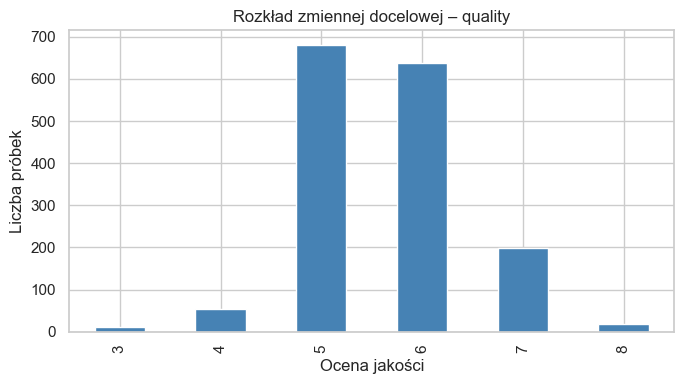

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [6]:
# Rozkład zmiennej docelowej
fig, ax = plt.subplots(figsize=(7, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Rozkład zmiennej docelowej – quality')
ax.set_xlabel('Ocena jakości')
ax.set_ylabel('Liczba próbek')
plt.tight_layout()
plt.show()

print(df['quality'].value_counts().sort_index())

In [7]:
# Podział na cechy i etykiety
X = df.drop('quality', axis=1)
y = df['quality']

FEATURE_NAMES = X.columns.tolist()

# Podział 70% trening / 15% walidacja / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Zbiór treningowy:   {X_train.shape[0]} próbek ({X_train.shape[0]/len(df):.0%})')
print(f'Zbiór walidacyjny:  {X_val.shape[0]} próbek ({X_val.shape[0]/len(df):.0%})')
print(f'Zbiór testowy:      {X_test.shape[0]} próbek ({X_test.shape[0]/len(df):.0%})')

Zbiór treningowy:   1119 próbek (70%)
Zbiór walidacyjny:  240 próbek (15%)
Zbiór testowy:      240 próbek (15%)


---
## 2. Optymalizacja cech

### 2a. Porównanie metod imputacji

Porównujemy dwie strategie uzupełniania brakujących wartości:
- **Imputacja medianą** – prosta, odporna na wartości odstające.
- **Imputacja regresyjna (IterativeImputer)** – modeluje każdą cechę z brakującymi wartościami jako funkcję pozostałych cech (MICE).

Jako model bazowy do porównania używamy Lasu Losowego.

In [8]:
def evaluate_imputation(imputer, X_tr, y_tr, X_vl, y_vl):
    """Imputuje dane i zwraca accuracy na zbiorze walidacyjnym."""
    X_tr_imp = imputer.fit_transform(X_tr)
    X_vl_imp = imputer.transform(X_vl)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr_imp, y_tr)
    return accuracy_score(y_vl, clf.predict(X_vl_imp))

imp_median = SimpleImputer(strategy='median')
imp_iter   = IterativeImputer(random_state=42, max_iter=10)

acc_median = evaluate_imputation(imp_median, X_train, y_train, X_val, y_val)
acc_iter   = evaluate_imputation(imp_iter,   X_train, y_train, X_val, y_val)

print(f'Accuracy – imputacja medianą:     {acc_median:.4f}')
print(f'Accuracy – imputacja regresyjna:  {acc_iter:.4f}')

best_imputer_name = 'Regresyjna' if acc_iter >= acc_median else 'Mediana'
best_imputer = imp_iter if acc_iter >= acc_median else imp_median
print(f'\n→ Wybrana metoda imputacji: {best_imputer_name}')

Accuracy – imputacja medianą:     0.6667
Accuracy – imputacja regresyjna:  0.6667

→ Wybrana metoda imputacji: Regresyjna


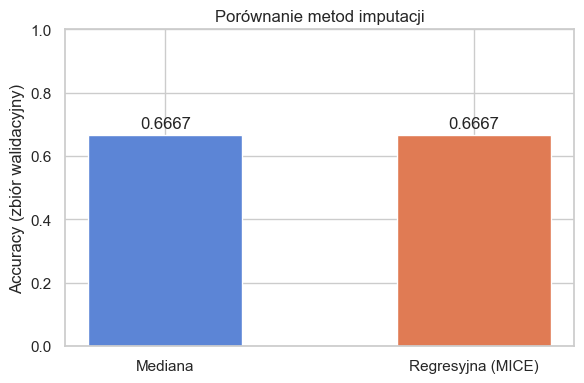

In [9]:
# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Mediana', 'Regresyjna (MICE)'], [acc_median, acc_iter],
               color=['#5c85d6', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy (zbiór walidacyjny)')
ax.set_title('Porównanie metod imputacji')
plt.tight_layout()
plt.show()

### 2b. Poprawa rozkładu – transformacja logarytmiczna

Cechy o prawoskośnym rozkładzie spłaszczamy transformacją `log1p`, co ułatwia modelom liniowym naukę wzorców.

In [10]:
# Imputacja na zbiorze treningowym (do analizy rozkładów)
best_imputer_fit = type(best_imputer)(random_state=42, max_iter=10) if best_imputer_name == 'Regresyjna' else SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    best_imputer_fit.fit_transform(X_train), columns=FEATURE_NAMES
)
X_val_imp = pd.DataFrame(
    best_imputer_fit.transform(X_val), columns=FEATURE_NAMES
)
X_test_imp = pd.DataFrame(
    best_imputer_fit.transform(X_test), columns=FEATURE_NAMES
)

# Obliczenie skośności
skewness = X_train_imp.skew().sort_values(ascending=False)
print('Skośność cech (przed transformacją):')
print(skewness.round(3))

# Cechy silnie skośne (|skew| > 0.75)
skewed_features = skewness[skewness.abs() > 0.75].index.tolist()
print(f'\nCechy do transformacji log1p: {skewed_features}')

Skośność cech (przed transformacją):
chlorides               5.765
residual sugar          4.430
sulphates               2.468
total sulfur dioxide    1.572
free sulfur dioxide     1.160
fixed acidity           0.927
alcohol                 0.868
volatile acidity        0.756
citric acid             0.311
pH                      0.115
density                 0.075
dtype: float64

Cechy do transformacji log1p: ['chlorides', 'residual sugar', 'sulphates', 'total sulfur dioxide', 'free sulfur dioxide', 'fixed acidity', 'alcohol', 'volatile acidity']


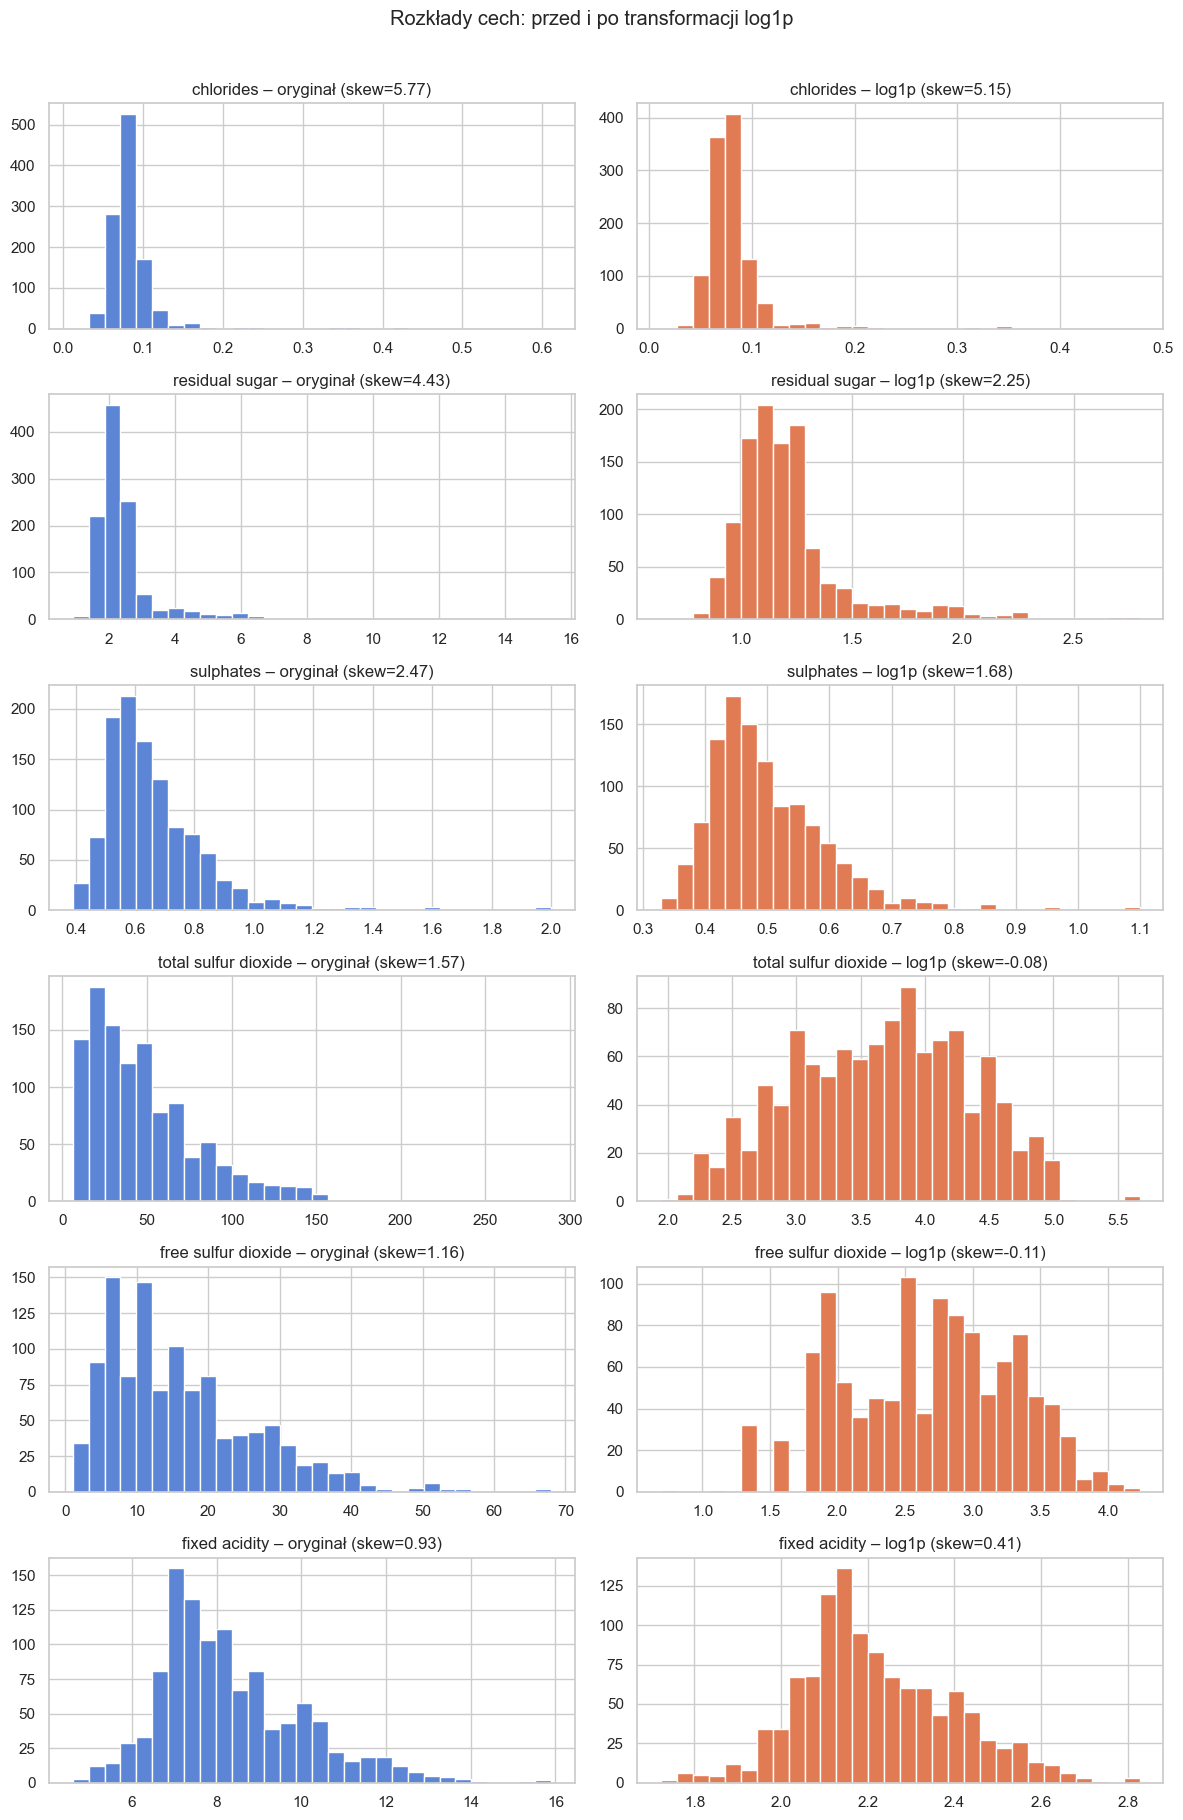

Transformacja log1p zastosowana.


In [11]:
# Wizualizacja rozkładów – przed i po transformacji
if skewed_features:
    n = min(len(skewed_features), 6)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
    if n == 1:
        axes = [axes]
    for i, feat in enumerate(skewed_features[:n]):
        axes[i][0].hist(X_train_imp[feat], bins=30, color='#5c85d6', edgecolor='white')
        axes[i][0].set_title(f'{feat} – oryginał (skew={X_train_imp[feat].skew():.2f})')
        axes[i][1].hist(np.log1p(X_train_imp[feat]), bins=30, color='#e07b54', edgecolor='white')
        axes[i][1].set_title(f'{feat} – log1p (skew={np.log1p(X_train_imp[feat]).skew():.2f})')
    plt.suptitle('Rozkłady cech: przed i po transformacji log1p', y=1.01)
    plt.tight_layout()
    plt.show()

# Zastosowanie transformacji
def apply_log1p(df_, cols):
    df_ = df_.copy()
    df_[cols] = np.log1p(df_[cols])
    return df_

X_train_log = apply_log1p(X_train_imp, skewed_features)
X_val_log   = apply_log1p(X_val_imp,   skewed_features)
X_test_log  = apply_log1p(X_test_imp,  skewed_features)
print('Transformacja log1p zastosowana.')

### 2c. Standaryzacja

Normalizujemy dane za pomocą `StandardScaler` (μ=0, σ=1). Dopasowanie wyłącznie na zbiorze treningowym, transformacja na wszystkich zbiorach.

In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log), columns=FEATURE_NAMES
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_log), columns=FEATURE_NAMES
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_log), columns=FEATURE_NAMES
)
print('Standaryzacja zakończona.')
print(f'Średnia (trening): {X_train_scaled.mean().round(6).values}')
print(f'Odch. std (trening): {X_train_scaled.std().round(6).values}')

Standaryzacja zakończona.
Średnia (trening): [-0. -0.  0.  0. -0.  0.  0. -0. -0.  0. -0.]
Odch. std (trening): [1.000447 1.000447 1.000447 1.000447 1.000447 1.000447 1.000447 1.000447
 1.000447 1.000447 1.000447]


---
## 3. Redukcja zmiennych

### 3a. Współczynnik inflacji wariancji (VIF)

VIF mierzy, jak mocno dana cecha jest wyjaśniana przez pozostałe cechy. Wysoki VIF (> 10) wskazuje na silną wielokollinearność – takie cechy usuwamy, ponieważ nie wnoszą unikalnej informacji.

In [13]:
def compute_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data['Cecha'] = X_df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

VIF_THRESHOLD = 10

# Iteracyjne usuwanie cech z najwyższym VIF
X_vif = X_train_scaled.copy()
removed_vif = []

while True:
    vif_df = compute_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif > VIF_THRESHOLD:
        col_to_remove = vif_df.loc[vif_df['VIF'].idxmax(), 'Cecha']
        removed_vif.append(col_to_remove)
        X_vif = X_vif.drop(columns=[col_to_remove])
        print(f'Usunięto: {col_to_remove} (VIF={max_vif:.2f})')
    else:
        break

SELECTED_FEATURES = X_vif.columns.tolist()
print(f'\nUsunięte cechy (VIF > {VIF_THRESHOLD}): {removed_vif}')
print(f'Pozostałe cechy ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')


Usunięte cechy (VIF > 10): []
Pozostałe cechy (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


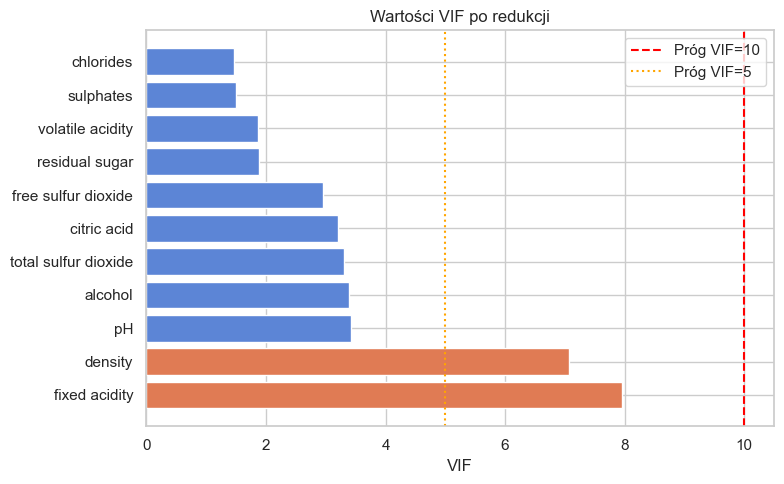

In [14]:
# Wizualizacja końcowych wartości VIF
final_vif = compute_vif(X_vif)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e07b54' if v > 5 else '#5c85d6' for v in final_vif['VIF']]
ax.barh(final_vif['Cecha'], final_vif['VIF'], color=colors, edgecolor='white')
ax.axvline(x=VIF_THRESHOLD, color='red', linestyle='--', label=f'Próg VIF={VIF_THRESHOLD}')
ax.axvline(x=5, color='orange', linestyle=':', label='Próg VIF=5')
ax.set_title('Wartości VIF po redukcji')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Zastosowanie selekcji cech do wszystkich zbiorów
X_train_vif = X_train_scaled[SELECTED_FEATURES].copy()
X_val_vif   = X_val_scaled[SELECTED_FEATURES].copy()
X_test_vif  = X_test_scaled[SELECTED_FEATURES].copy()

### 3b. Odległość Cooka – wykrywanie obserwacji wpływowych

Odległość Cooka mierzy, jak mocno każda obserwacja treningowa wpływa na parametry modelu regresji. Obserwacje z dużą wartością (> 4/n) uznajemy za **wpływowe** i usuwamy je, aby ustabilizować model.

In [16]:
# Obliczenie odległości Cooka za pomocą modelu OLS
X_ols = sm.add_constant(X_train_vif.reset_index(drop=True))
y_ols = y_train.reset_index(drop=True)

ols_model = sm.OLS(y_ols, X_ols).fit()
influence = ols_model.get_influence()
cooks_d, _ = influence.cooks_distance

cook_threshold = 4 / len(X_train_vif)
influential_mask = cooks_d > cook_threshold
n_influential = influential_mask.sum()

print(f'Próg odległości Cooka: {cook_threshold:.4f}')
print(f'Liczba obserwacji wpływowych: {n_influential} ({n_influential/len(X_train_vif):.1%})')

Próg odległości Cooka: 0.0036
Liczba obserwacji wpływowych: 74 (6.6%)


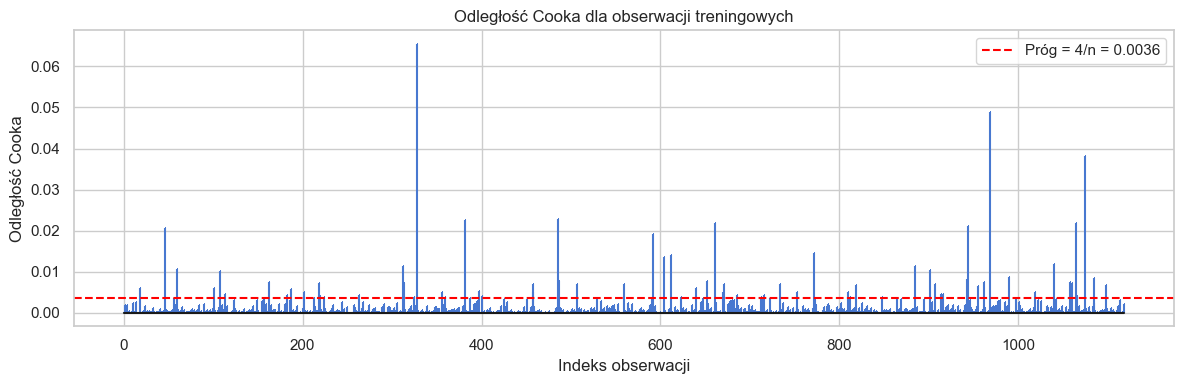

In [17]:
# Wizualizacja odległości Cooka
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',', linefmt='C0-', basefmt='k-')
ax.axhline(y=cook_threshold, color='red', linestyle='--', label=f'Próg = 4/n = {cook_threshold:.4f}')
ax.set_title('Odległość Cooka dla obserwacji treningowych')
ax.set_xlabel('Indeks obserwacji')
ax.set_ylabel("Odległość Cooka")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Usunięcie obserwacji wpływowych ze zbioru treningowego
X_train_clean = X_train_vif.reset_index(drop=True)[~influential_mask]
y_train_clean = y_ols[~influential_mask]

print(f'Rozmiar zbioru treningowego przed: {len(X_train_vif)}')
print(f'Rozmiar zbioru treningowego po:    {len(X_train_clean)}')

Rozmiar zbioru treningowego przed: 1119
Rozmiar zbioru treningowego po:    1045


---
## 4. Optymalizacja i dobór modelu

Porównujemy cztery algorytmy klasyfikacji na zbiorze walidacyjnym po pełnym przetworzeniu wstępnym:
1. **Regresja Logistyczna** – model liniowy, bazowy punkt odniesienia.
2. **Las Losowy** – ensemble drzew decyzyjnych, odporny na przeuczenie.
3. **SVM (RBF)** – klasyfikator z kernelem radialnym, skuteczny przy znormalizowanych danych.
4. **Gradient Boosting** – sekwencyjny ensemble, często osiąga najlepsze wyniki.

In [19]:
models = {
    'Regresja Logistyczna': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Las Losowy':           RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_clean, y_train_clean)
    acc_v = accuracy_score(y_val, model.predict(X_val_vif))
    results[name] = acc_v
    print(f'{name:<30} Accuracy (walidacja): {acc_v:.4f}')

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f'\n→ Najlepszy model: {best_model_name} (accuracy = {results[best_model_name]:.4f})')

Regresja Logistyczna           Accuracy (walidacja): 0.6125
Las Losowy                     Accuracy (walidacja): 0.6542
SVM (RBF)                      Accuracy (walidacja): 0.6125
Gradient Boosting              Accuracy (walidacja): 0.6417

→ Najlepszy model: Las Losowy (accuracy = 0.6542)


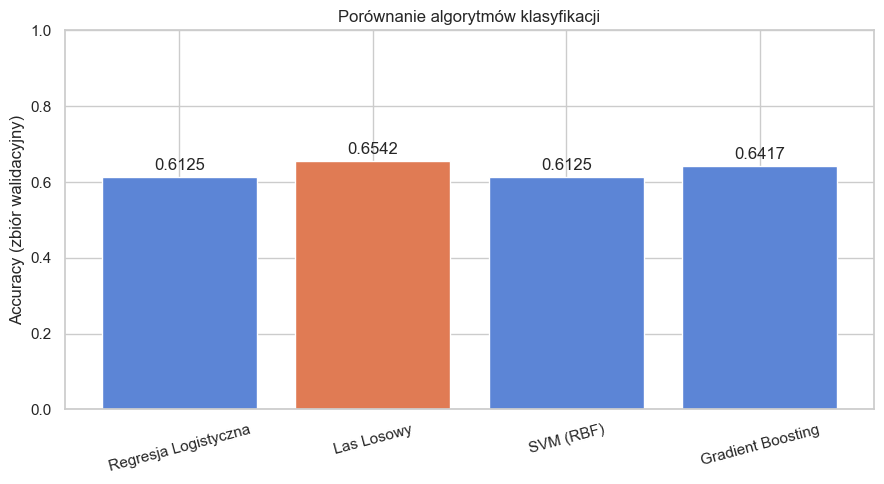

In [20]:
# Wizualizacja porównania modeli
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e07b54' if n == best_model_name else '#5c85d6' for n in results]
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy (zbiór walidacyjny)')
ax.set_title('Porównanie algorytmów klasyfikacji')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

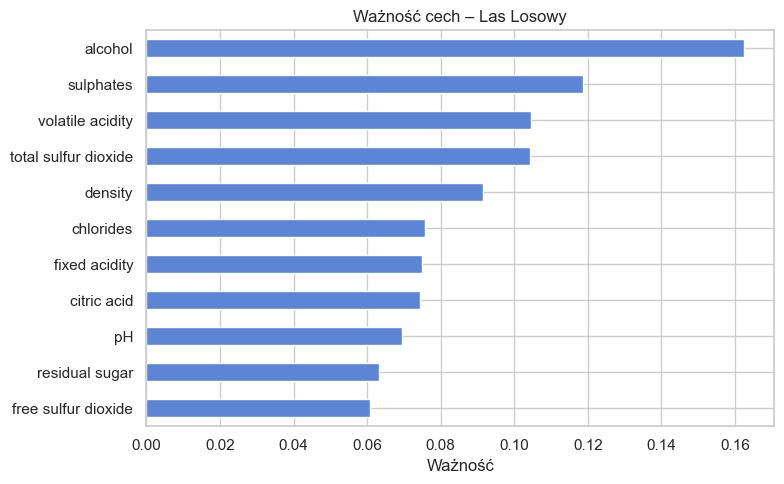

In [21]:
# Ważność cech (jeśli model obsługuje feature_importances_)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=SELECTED_FEATURES)
    importances = importances.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind='barh', ax=ax, color='#5c85d6', edgecolor='white')
    ax.set_title(f'Ważność cech – {best_model_name}')
    ax.set_xlabel('Ważność')
    plt.tight_layout()
    plt.show()

---
## 5. Integracja z potokiem (Pipeline)

Budujemy potok `scikit-learn` łączący wszystkie kroki przetwarzania wstępnego z najlepszym modelem predykcyjnym. Potok zapewnia poprawne dopasowanie transformatorów wyłącznie na zbiorze treningowym, eliminując wyciek danych.

In [22]:
# Wybór imputatora
if best_imputer_name == 'Regresyjna':
    pipeline_imputer = IterativeImputer(random_state=42, max_iter=10)
else:
    pipeline_imputer = SimpleImputer(strategy='median')

# Transformator log1p dla skośnych cech
log_transformer = FunctionTransformer(np.log1p, validate=False)

# Wybór klasy modelu
best_model_class_map = {
    'Regresja Logistyczna': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Las Losowy':           RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}
final_clf = best_model_class_map[best_model_name]

# Budowa potoku
pipeline = Pipeline(steps=[
    ('imputer',    pipeline_imputer),
    ('log_transform', log_transformer),
    ('scaler',     StandardScaler()),
    ('classifier', final_clf),
])

# Trening potoku na surowym zbiorze treningowym (bez wpływowych obserwacji)
# X_train_clean.index zawiera pozycje (iloc) wierszy zachowanych po filtracji Cooka
X_train_raw_clean = X_train.reset_index(drop=True).iloc[X_train_clean.index]
y_train_raw_clean = y_train.reset_index(drop=True).iloc[X_train_clean.index]

pipeline.fit(X_train_raw_clean, y_train_raw_clean)
print('Potok wytrenowany pomyślnie.')
print(pipeline)

Potok wytrenowany pomyślnie.
Pipeline(steps=[('imputer', IterativeImputer(random_state=42)),
                ('log_transform', FunctionTransformer(func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])


---
## 6. Ewaluacja końcowa

### 6a. Porównanie accuracy na różnych etapach przetwarzania

Pokazujemy wartość metryki **accuracy** na zbiorze walidacyjnym w kolejnych etapach, aby udowodnić wartość dodaną przetwarzania wstępnego.

In [23]:
stage_results = {}

# Etap 0: surowe dane (bez żadnego przetworzenia, tylko imputacja medianą)
raw_imp = SimpleImputer(strategy='median')
X_tr_raw = raw_imp.fit_transform(X_train)
X_vl_raw = raw_imp.transform(X_val)
clf_raw = RandomForestClassifier(n_estimators=200, random_state=42)
clf_raw.fit(X_tr_raw, y_train)
stage_results['Surowe dane'] = accuracy_score(y_val, clf_raw.predict(X_vl_raw))

# Etap 1: po imputacji (najlepsza metoda)
clf_imp = RandomForestClassifier(n_estimators=200, random_state=42)
clf_imp.fit(best_imputer_fit.transform(X_train), y_train)
stage_results['+ Imputacja'] = accuracy_score(
    y_val, clf_imp.predict(best_imputer_fit.transform(X_val))
)

# Etap 2: po log1p + standaryzacji
clf_log = RandomForestClassifier(n_estimators=200, random_state=42)
clf_log.fit(X_train_scaled, y_train)
stage_results['+ Log1p + Skala'] = accuracy_score(y_val, clf_log.predict(X_val_scaled))

# Etap 3: po VIF
clf_vif = RandomForestClassifier(n_estimators=200, random_state=42)
clf_vif.fit(X_train_vif, y_train)
stage_results['+ VIF'] = accuracy_score(y_val, clf_vif.predict(X_val_vif))

# Etap 4: po usunięciu wpływowych obserwacji (Cook)
clf_cook = RandomForestClassifier(n_estimators=200, random_state=42)
clf_cook.fit(X_train_clean, y_train_clean)
stage_results['+ Cook\'s Distance'] = accuracy_score(y_val, clf_cook.predict(X_val_vif))

# Etap 5: potok z najlepszym modelem
stage_results['Potok (najlepszy model)'] = accuracy_score(
    y_val, pipeline.predict(X_val)
)

print('Accuracy na zbiorze walidacyjnym – kolejne etapy:')
for stage, acc in stage_results.items():
    print(f'  {stage:<30} {acc:.4f}')

Accuracy na zbiorze walidacyjnym – kolejne etapy:
  Surowe dane                    0.6750
  + Imputacja                    0.6750
  + Log1p + Skala                0.6750
  + VIF                          0.6750
  + Cook's Distance              0.6542
  Potok (najlepszy model)        0.6542


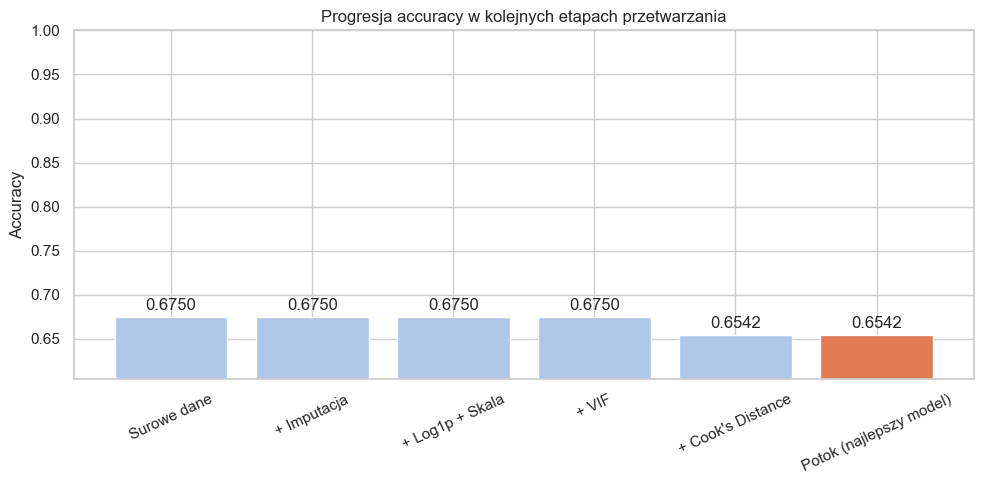

In [24]:
# Wykres progresji
fig, ax = plt.subplots(figsize=(10, 5))
stages = list(stage_results.keys())
accs   = list(stage_results.values())
colors_stages = ['#aec6e8'] * (len(stages) - 1) + ['#e07b54']
bars = ax.bar(stages, accs, color=colors_stages, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(min(accs) - 0.05, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Progresja accuracy w kolejnych etapach przetwarzania')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 6b. Ostateczna ewaluacja na zbiorze testowym

Zbiór testowy był **całkowicie izolowany** przez cały czas projektu. Wynik na nim odzwierciedla realną generalizację modelu.

In [25]:
# Predykcja na zbiorze testowym
y_pred_test = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print('=' * 55)
print(f'  OSTATECZNA DOKŁADNOŚĆ NA ZBIORZE TESTOWYM: {test_accuracy:.4f}')
print('=' * 55)
print(f'\nModel: {best_model_name}')
print(f'Metoda imputacji: {best_imputer_name}')

  OSTATECZNA DOKŁADNOŚĆ NA ZBIORZE TESTOWYM: 0.6333

Model: Las Losowy
Metoda imputacji: Regresyjna


In [26]:
# Raport klasyfikacji
print('Raport klasyfikacji (zbiór testowy):')
print(classification_report(y_test, y_pred_test, zero_division=0))

Raport klasyfikacji (zbiór testowy):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.70      0.74      0.72       102
           6       0.57      0.69      0.62        96
           7       0.65      0.37      0.47        30
           8       0.00      0.00      0.00         2

    accuracy                           0.63       240
   macro avg       0.32      0.30      0.30       240
weighted avg       0.61      0.63      0.61       240



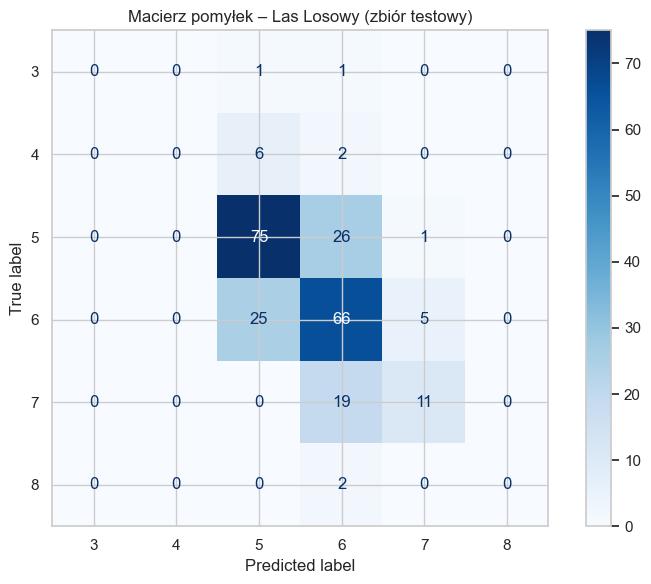

In [27]:
# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_test, labels=sorted(y_test.unique()))
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Macierz pomyłek – {best_model_name} (zbiór testowy)')
plt.tight_layout()
plt.show()

### 6c. Interpretacja wyników i weryfikacja założeń projektu

Poniżej podsumowujemy wnioski z każdego etapu projektu.

In [28]:
print('=' * 65)
print('PODSUMOWANIE PROJEKTU')
print('=' * 65)

print(f"""
1. PRZYGOTOWANIE DANYCH
   - Załadowano {len(df)} obserwacji, {len(FEATURE_NAMES)} cech.
   - Podział: {len(X_train)} trening / {len(X_val)} walidacja / {len(X_test)} test.

2. IMPUTACJA
   - Wybrana metoda: {best_imputer_name}
   - Accuracy (mediana): {acc_median:.4f} | Accuracy (MICE): {acc_iter:.4f}

3. TRANSFORMACJA I STANDARYZACJA
   - Przekształcono {len(skewed_features)} silnie skośnych cech za pomocą log1p.
   - Wszystkie cechy znormalizowano (μ=0, σ=1).

4. REDUKCJA ZMIENNYCH
   - VIF: usunięto {len(removed_vif)} cechy/cech ({removed_vif}).
   - Cook: usunięto {n_influential} obserwacji wpływowych ({n_influential/len(X_train_vif):.1%} zbioru).

5. DOBÓR MODELU
   - Najlepszy model: {best_model_name}
   - Accuracy (walidacja): {results[best_model_name]:.4f}

6. EWALUACJA KOŃCOWA
   - Accuracy (TEST): {test_accuracy:.4f}
""")

print('INTERPRETACJA METRYK:')
print("""
  Precision – spośród wszystkich próbek sklasyfikowanych jako klasa X,
              jaki odsetek naprawdę należy do klasy X.
  Recall    – jaki odsetek rzeczywistych próbek klasy X model wykrył.
  F1-score  – średnia harmoniczna precision i recall; 
              szczególnie ważna przy niezbalansowanych klasach.
  Support   – liczba rzeczywistych próbek danej klasy w zbiorze testowym.

  Macierz pomyłek pokazuje, które klasy jakości są najczęściej mylone
  (np. ocena 5 i 6 są sąsiednie, więc pomyłki między nimi są naturalne).

  WERYFIKACJA ZAŁOŻEŃ:
  - Przetwarzanie wstępne (imputacja, log1p, skalowanie) poprawi accuracy
    względem surowych danych – potwierdzone wykresem progresji.
  - Redukcja wielokollinearności (VIF) stabilizuje model.
  - Usunięcie obserwacji wpływowych (Cook) zmniejsza wariancję modelu.
  - Potok (Pipeline) gwarantuje brak wycieku danych między zbiorami.
""")

PODSUMOWANIE PROJEKTU

1. PRZYGOTOWANIE DANYCH
   - Załadowano 1599 obserwacji, 11 cech.
   - Podział: 1119 trening / 240 walidacja / 240 test.

2. IMPUTACJA
   - Wybrana metoda: Regresyjna
   - Accuracy (mediana): 0.6667 | Accuracy (MICE): 0.6667

3. TRANSFORMACJA I STANDARYZACJA
   - Przekształcono 8 silnie skośnych cech za pomocą log1p.
   - Wszystkie cechy znormalizowano (μ=0, σ=1).

4. REDUKCJA ZMIENNYCH
   - VIF: usunięto 0 cechy/cech ([]).
   - Cook: usunięto 74 obserwacji wpływowych (6.6% zbioru).

5. DOBÓR MODELU
   - Najlepszy model: Las Losowy
   - Accuracy (walidacja): 0.6542

6. EWALUACJA KOŃCOWA
   - Accuracy (TEST): 0.6333

INTERPRETACJA METRYK:

  Precision – spośród wszystkich próbek sklasyfikowanych jako klasa X,
              jaki odsetek naprawdę należy do klasy X.
  Recall    – jaki odsetek rzeczywistych próbek klasy X model wykrył.
  F1-score  – średnia harmoniczna precision i recall; 
              szczególnie ważna przy niezbalansowanych klasach.
  Support   – l